# Libraries

In [1]:
import os

os.chdir("..")

import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import numpy as np

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

# Functiones

In [2]:
def winzorize(col_name, df, c_up=True, c_low=True):

    p25 = df[col_name].quantile(0.25)
    p75 = df[col_name].quantile(0.75)

    irq = p75 - p25

    upper = p75 + 1.5 * irq
    lower = p25 - 1.5 * irq

    if c_up:
        df[col_name] = df[col_name].clip(upper=upper)

    if c_low:
        df[col_name] = df[col_name].clip(lower=lower)

    return df[col_name]

In [3]:
def check_data(column_name: str, df: pd.DataFrame):

    print(f"\nType of {column_name}: {df[column_name].dtype}")
    print(
        f"\nDistribution of {column_name}: {df[column_name].value_counts(dropna=False).head()}"
    )
    print(f"\nNumber of unique values in  {column_name}: {df[column_name].nunique()}")
    print(f"\nUnique  values in  {column_name}: {df[column_name].unique()}")
    print(f"\nNumber of Null values in {column_name}: {df[column_name].isnull().sum()}")
    print(f"\n% of Null values in {column_name}: {df[column_name].isnull().mean()}")

# Load data

We are going to work only with 3 variables to start

In [4]:
train_df = pd.read_csv(
    "/Users/luisfernandocorcueraleon/Desktop/code/Credit-Score-Classification/data/train.csv"
)

train_sample_df = train_df[
    [
        "ID",
        "Customer_ID",
        "Month",
        "Occupation",
        "Annual_Income",
        "Num_Credit_Inquiries",
        "Num_Bank_Accounts",
        "Num_of_Delayed_Payment",
        "Payment_Behaviour",
        "Credit_Score",
    ]
]
target_col = "Credit_Score"

/var/folders/1f/54wv342x795c_zyzqlgyjjkw0000gn/T/ipykernel_86858/2472480031.py:1: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(


In [5]:
train_sample_df.head()

,ID,Customer_ID,Month,Occupation,Annual_Income,Num_Credit_Inquiries,Num_Bank_Accounts,Num_of_Delayed_Payment,Payment_Behaviour,Credit_Score
0,0x1602,CUS_0xd40,January,Scientist,19114.12,4.00,3,7,High_spent_Small_value_payments,Good
1,0x1603,CUS_0xd40,February,Scientist,19114.12,4.00,3,NaN,Low_spent_Large_value_payments,Good
2,0x1604,CUS_0xd40,March,Scientist,19114.12,4.00,3,7,Low_spent_Medium_value_payments,Good
3,0x1605,CUS_0xd40,April,Scientist,19114.12,4.00,3,4,Low_spent_Small_value_payments,Good
4,0x1606,CUS_0xd40,May,Scientist,19114.12,4.00,3,NaN,High_spent_Medium_value_payments,Good


# Check data

In [6]:
train_sample_df["Annual_Income"].isnull().sum()

np.int64(0)

In [7]:
train_sample_df["Annual_Income"].dtype

<StringDtype(storage='python', na_value=nan)>

In [8]:
train_sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  str    
 1   Customer_ID             100000 non-null  str    
 2   Month                   100000 non-null  str    
 3   Occupation              100000 non-null  str    
 4   Annual_Income           100000 non-null  str    
 5   Num_Credit_Inquiries    98035 non-null   float64
 6   Num_Bank_Accounts       100000 non-null  int64  
 7   Num_of_Delayed_Payment  92998 non-null   str    
 8   Payment_Behaviour       100000 non-null  str    
 9   Credit_Score            100000 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 7.6 MB


In [9]:
train_sample_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Num_Credit_Inquiries,"98,035.00",27.75,193.18,0.00,3.00,6.00,9.00,"2,597.00"
Num_Bank_Accounts,"100,000.00",17.09,117.40,-1.00,3.00,6.00,7.00,"1,798.00"


In [10]:
COLUMNS = train_sample_df.columns

for col in COLUMNS:
    print("=" * 100)
    check_data(col, train_sample_df)


Type of ID: str

Distribution of ID: ID
0x1602    1
0x1603    1
0x1604    1
0x1605    1
0x1606    1
Name: count, dtype: int64

Number of unique values in  ID: 100000

Unique  values in  ID: <StringArray>
[ '0x1602',  '0x1603',  '0x1604',  '0x1605',  '0x1606',  '0x1607',  '0x1608',
  '0x1609',  '0x160e',  '0x160f',
 ...
 '0x25fe0', '0x25fe1', '0x25fe6', '0x25fe7', '0x25fe8', '0x25fe9', '0x25fea',
 '0x25feb', '0x25fec', '0x25fed']
Length: 100000, dtype: str

Number of Null values in ID: 0

% of Null values in ID: 0.0

Type of Customer_ID: str

Distribution of Customer_ID: Customer_ID
CUS_0xd40     8
CUS_0x21b1    8
CUS_0x2dbc    8
CUS_0xb891    8
CUS_0x1cdb    8
Name: count, dtype: int64

Number of unique values in  Customer_ID: 12500

Unique  values in  Customer_ID: <StringArray>
[ 'CUS_0xd40', 'CUS_0x21b1', 'CUS_0x2dbc', 'CUS_0xb891', 'CUS_0x1cdb',
 'CUS_0x95ee', 'CUS_0x284a', 'CUS_0x5407', 'CUS_0x4157', 'CUS_0xba08',
 ...
 'CUS_0x2654', 'CUS_0xb11c', 'CUS_0xad4f', 'CUS_0x51b3', 'CUS_

Tasks:

1. Occupation: No null values but replace and check the percentage of values of _____
2. Annual income: No null values but in type string and with _ at the end, check the position and consider to replac those with nothing
3. num_inquieres: 2% of null values and imposible values to replace
4. Num_Bank_Accounts: Imposible numbers to check an dreplace 
5. Num_of_Delayed_Payment: change type and 7% of null values
6. Payment_Behaviour: Change the trange value as null
7. Target: Unify categories good and standard

In [11]:
train_sample_df.groupby("Month").agg(
    unique_clients_per_month=("ID", "nunique"),
    num_inquieres_per_month=("Num_Credit_Inquiries", "sum"),
    num_bank_accounts_per_month=("Num_Bank_Accounts", "sum"),
)

,unique_clients_per_month,num_inquieres_per_month,num_bank_accounts_per_month
Month,,,
April,12500,"390,058.00",226224
August,12500,"321,897.00",211749
February,12500,"327,231.00",236548
January,12500,"301,592.00",215939
July,12500,"362,063.00",198399
June,12500,"359,244.00",192041
March,12500,"309,983.00",218021
May,12500,"348,820.00",210207


In [12]:
train_sample_df.groupby("Occupation").agg(
    unique_clients_per_month=("ID", "nunique"),
    num_inquieres_per_month=("Num_Credit_Inquiries", "sum"),
    num_bank_accounts_per_month=("Num_Bank_Accounts", "sum"),
    avg_annual_income=(
        "Occupation",
        lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    ),
)

,unique_clients_per_month,num_inquieres_per_month,num_bank_accounts_per_month,avg_annual_income
Occupation,,,,
Accountant,6271,"172,184.00",117975,Accountant
Architect,6355,"159,192.00",119192,Architect
Developer,6235,"180,030.00",109517,Developer
Doctor,6087,"169,184.00",106462,Doctor
Engineer,6350,"176,474.00",118397,Engineer
Entrepreneur,6174,"183,828.00",96284,Entrepreneur
Journalist,6085,"172,514.00",104741,Journalist
Lawyer,6575,"167,427.00",107512,Lawyer
Manager,5973,"168,538.00",97575,Manager


# Cleaning

### Occupation

In [13]:
train_sample_df["Occupation"].unique()

<StringArray>
[    'Scientist',       '_______',       'Teacher',      'Engineer',
  'Entrepreneur',     'Developer',        'Lawyer', 'Media_Manager',
        'Doctor',    'Journalist',       'Manager',    'Accountant',
      'Musician',      'Mechanic',        'Writer',     'Architect']
Length: 16, dtype: str

In [14]:
train_sample_df["Occupation"] = train_sample_df["Occupation"].replace("_______", np.nan)

In [15]:
train_sample_df["Occupation"].value_counts(dropna=False)

Occupation
NaN              7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

In [16]:
train_sample_df.groupby(["Customer_ID"])["Occupation"].count().value_counts()

Occupation
8    6950
7    4248
6    1113
5     169
4      19
3       1
Name: count, dtype: int64

In [17]:
train_sample_df.groupby(["Customer_ID"])["Occupation"].nunique().value_counts()

Occupation
1    12500
Name: count, dtype: int64

In [18]:
train_sample_df["Occupation_cleaned"] = (
    train_sample_df.groupby("Customer_ID", as_index=True)["Occupation"].bfill().ffill()
)

In [19]:
print(train_sample_df["Occupation"].isna().sum())
train_sample_df["Occupation"] = train_sample_df["Occupation"].fillna(
    train_sample_df["Occupation_cleaned"]
)
print(train_sample_df["Occupation"].isna().sum())

7062
0


In [20]:
md = train_sample_df["Occupation"].mode()[0]

train_sample_df["Occupation"] = train_sample_df["Occupation"].fillna(md)

### 2. Annual income

In [21]:
msk = train_sample_df["Annual_Income"].str.contains("_")

In [22]:
error_annual_income = train_sample_df[msk]
print(len(error_annual_income))
print(error_annual_income["Annual_Income"].str.endswith("_").sum())

6980
6980


In [23]:
train_sample_df["Annual_Income"] = train_sample_df["Annual_Income"].str.replace("_", "")
train_sample_df["Annual_Income"] = train_sample_df["Annual_Income"].astype("double")

In [24]:
train_sample_df["Annual_Income"].describe().T

count      100,000.00
mean       176,415.70
std      1,429,618.05
min          7,005.93
25%         19,457.50
50%         37,578.61
75%         72,790.92
max     24,198,062.00
Name: Annual_Income, dtype: float64

### num_inqueries

In [25]:
train_sample_df["Num_Credit_Inquiries"].describe()

count   98,035.00
mean        27.75
std        193.18
min          0.00
25%          3.00
50%          6.00
75%          9.00
max      2,597.00
Name: Num_Credit_Inquiries, dtype: float64

In [26]:
p25 = train_sample_df["Num_Credit_Inquiries"].quantile(0.25)
p75 = train_sample_df["Num_Credit_Inquiries"].quantile(0.75)

irq = p75 - p25

upper = p75 + 1.5 * irq
upper

np.float64(18.0)

In [27]:
train_sample_df["Num_Credit_Inquiries"] = train_sample_df["Num_Credit_Inquiries"].clip(
    upper=upper
)

train_sample_df["Num_Credit_Inquiries"].describe()

count   98,035.00
mean         5.99
std          4.14
min          0.00
25%          3.00
50%          6.00
75%          9.00
max         18.00
Name: Num_Credit_Inquiries, dtype: float64

In [28]:
train_sample_df.groupby(["Customer_ID"])["Num_Credit_Inquiries"].nunique().value_counts(
    dropna=False
)

Num_Credit_Inquiries
2    7020
1    4670
3     810
Name: count, dtype: int64

In [29]:
train_sample_df[
    train_sample_df.groupby("Customer_ID")["Num_Credit_Inquiries"].transform("nunique")
    == 3
]

,ID,Customer_ID,Month,Occupation,Annual_Income,Num_Credit_Inquiries,Num_Bank_Accounts,Num_of_Delayed_Payment,Payment_Behaviour,Credit_Score,Occupation_cleaned
192,0x1722,CUS_0xa5f9,January,Mechanic,"57,983.12",12.00,9,19,Low_spent_Small_value_payments,Poor,Mechanic
193,0x1723,CUS_0xa5f9,February,Mechanic,"57,983.12",18.00,9,21,High_spent_Medium_value_payments,Standard,Mechanic
194,0x1724,CUS_0xa5f9,March,Mechanic,"57,983.12",17.00,9,NaN,Low_spent_Small_value_payments,Poor,Mechanic
195,0x1725,CUS_0xa5f9,April,Mechanic,"57,983.12",17.00,9,22,High_spent_Medium_value_payments,Poor,Mechanic
196,0x1726,CUS_0xa5f9,May,Mechanic,"57,983.12",17.00,9,21,Low_spent_Small_value_payments,Poor,Mechanic
...,...,...,...,...,...,...,...,...,...,...,...
99875,0x25f35,CUS_0x3855,April,Scientist,"118,677.54",5.00,4,NaN,Low_spent_Medium_value_payments,Good,Scientist
99876,0x25f36,CUS_0x3855,May,Scientist,"118,677.54",5.00,4,11,High_spent_Large_value_payments,Good,Scientist
99877,0x25f37,CUS_0x3855,June,Scientist,"118,677.54",5.00,4,NaN,High_spent_Large_value_payments,Good,Scientist
99878,0x25f38,CUS_0x3855,July,Scientist,"118,677.54",5.00,4,12,!@9#%8,Good,Scientist


In [30]:
train_sample_df["Num_Credit_Inquiries"] = train_sample_df[
    "Num_Credit_Inquiries"
].fillna(
    train_sample_df.groupby("Customer_ID")["Num_Credit_Inquiries"].transform("mean")
)

In [31]:
train_sample_df["Num_Credit_Inquiries"].isnull().sum()

np.int64(0)

### Num_Bank_Accounts

In [32]:
train_sample_df["Num_Bank_Accounts"].describe()

count   100,000.00
mean         17.09
std         117.40
min          -1.00
25%           3.00
50%           6.00
75%           7.00
max       1,798.00
Name: Num_Bank_Accounts, dtype: float64

In [33]:
train_sample_df["Num_Bank_Accounts"] = winzorize(
    "Num_Bank_Accounts", train_sample_df, c_low=False
)

In [34]:
train_sample_df["Num_Bank_Accounts"].describe()

count   100,000.00
mean          5.47
std           2.72
min          -1.00
25%           3.00
50%           6.00
75%           7.00
max          13.00
Name: Num_Bank_Accounts, dtype: float64

In [35]:
train_sample_df["Num_Bank_Accounts"].value_counts()

Num_Bank_Accounts
 6     13001
 7     12823
 8     12765
 4     12186
 5     12118
 3     11950
 9      5443
 10     5247
 1      4490
 0      4328
 2      4304
 13     1315
-1        21
 11        9
Name: count, dtype: int64

In [36]:
train_sample_df["Num_Bank_Accounts"] = train_sample_df["Num_Bank_Accounts"].replace(
    -1, 0
)

In [37]:
train_sample_df["Num_Bank_Accounts"].describe()

count   100,000.00
mean          5.47
std           2.72
min           0.00
25%           3.00
50%           6.00
75%           7.00
max          13.00
Name: Num_Bank_Accounts, dtype: float64

### Num_of_Delayed_Payment

In [38]:
train_sample_df["Num_of_Delayed_Payment"].value_counts(dropna=False)

Num_of_Delayed_Payment
NaN     7002
19      5327
17      5261
16      5173
10      5153
        ... 
3336       1
3392       1
3688       1
221        1
2047       1
Name: count, Length: 750, dtype: int64

In [40]:
check = train_sample_df[train_sample_df["Num_of_Delayed_Payment"].str.contains("_")]
print(check["Num_of_Delayed_Payment"].str.endswith("_").sum())
print(len(check))

2744
2744


In [42]:
train_sample_df["Num_of_Delayed_Payment_cleaned"] = train_sample_df[
    "Num_of_Delayed_Payment"
].str.replace("_", "")
train_sample_df["Num_of_Delayed_Payment_cleaned"] = pd.to_numeric(
    train_sample_df["Num_of_Delayed_Payment_cleaned"], errors="coerce"
)

In [43]:
train_sample_df["Num_of_Delayed_Payment_cleaned"].describe()

count   92,998.00
mean        30.92
std        226.03
min         -3.00
25%          9.00
50%         14.00
75%         18.00
max      4,397.00
Name: Num_of_Delayed_Payment_cleaned, dtype: float64

In [44]:
train_sample_df["Num_of_Delayed_Payment_cleaned"] = winzorize(
    "Num_of_Delayed_Payment_cleaned", train_sample_df, c_low=True
)

In [45]:
train_sample_df[train_sample_df["Num_of_Delayed_Payment_cleaned"] < 0][
    "Num_of_Delayed_Payment_cleaned"
].value_counts()

Num_of_Delayed_Payment_cleaned
-1.00    316
-2.00    234
-3.00     94
Name: count, dtype: int64

In [ ]:
train_sample_df["Num_of_Delayed_Payment_cleaned"] = np.where(
    (train_sample_df["Num_of_Delayed_Payment_cleaned"] < 0),
    np.nan,
    train_sample_df["Num_of_Delayed_Payment_cleaned"],
)

In [47]:
print(train_sample_df["Num_of_Delayed_Payment_cleaned"].isna().sum())
print(train_sample_df["Num_of_Delayed_Payment_cleaned"].isna().mean())

7646
0.07646


In [50]:
train_sample_df.groupby("Customer_ID")[
    "Num_of_Delayed_Payment_cleaned"
].nunique().value_counts()

Num_of_Delayed_Payment_cleaned
3    4540
4    3316
2    2893
5     985
1     603
6     154
7       9
Name: count, dtype: int64

In [53]:
train_sample_df[train_sample_df["Num_of_Delayed_Payment_cleaned"].isnull()]

,ID,Customer_ID,Month,Occupation,Annual_Income,Num_Credit_Inquiries,Num_Bank_Accounts,Num_of_Delayed_Payment,Payment_Behaviour,Credit_Score,Occupation_cleaned,Num_of_Delayed_Payment_cleaned
1,0x1603,CUS_0xd40,February,Scientist,"19,114.12",4.00,3,NaN,Low_spent_Large_value_payments,Good,Scientist,NaN
4,0x1606,CUS_0xd40,May,Scientist,"19,114.12",4.00,3,NaN,High_spent_Medium_value_payments,Good,Scientist,NaN
10,0x1610,CUS_0x21b1,March,Teacher,"34,847.84",2.00,2,-1,High_spent_Large_value_payments,Standard,Teacher,NaN
30,0x162c,CUS_0xb891,July,Entrepreneur,"30,689.89",4.00,2,NaN,Low_spent_Large_value_payments,Standard,Entrepreneur,NaN
32,0x1632,CUS_0x1cdb,January,Developer,"35,547.71",4.00,7,NaN,!@9#%8,Standard,Developer,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
99973,0x25fc7,CUS_0xf16,June,Media_Manager,"16,680.35",8.00,1,NaN,Low_spent_Small_value_payments,Good,Media_Manager,NaN
99974,0x25fc8,CUS_0xf16,July,Media_Manager,"16,680.35",8.00,1,NaN,Low_spent_Small_value_payments,Good,Media_Manager,NaN
99992,0x25fe6,CUS_0x942c,January,Mechanic,"39,628.99",3.00,4,NaN,Low_spent_Small_value_payments,Poor,Mechanic,NaN
99993,0x25fe7,CUS_0x942c,February,Mechanic,"39,628.99",3.00,4,NaN,Low_spent_Medium_value_payments,Standard,Mechanic,NaN


In [54]:
train_sample_df[train_sample_df["Customer_ID"] == "CUS_0xd40"]

,ID,Customer_ID,Month,Occupation,Annual_Income,Num_Credit_Inquiries,Num_Bank_Accounts,Num_of_Delayed_Payment,Payment_Behaviour,Credit_Score,Occupation_cleaned,Num_of_Delayed_Payment_cleaned
0,0x1602,CUS_0xd40,January,Scientist,"19,114.12",4.00,3,7,High_spent_Small_value_payments,Good,Scientist,7.00
1,0x1603,CUS_0xd40,February,Scientist,"19,114.12",4.00,3,NaN,Low_spent_Large_value_payments,Good,Scientist,NaN
2,0x1604,CUS_0xd40,March,Scientist,"19,114.12",4.00,3,7,Low_spent_Medium_value_payments,Good,Scientist,7.00
3,0x1605,CUS_0xd40,April,Scientist,"19,114.12",4.00,3,4,Low_spent_Small_value_payments,Good,Scientist,4.00
4,0x1606,CUS_0xd40,May,Scientist,"19,114.12",4.00,3,NaN,High_spent_Medium_value_payments,Good,Scientist,NaN
5,0x1607,CUS_0xd40,June,Scientist,"19,114.12",4.00,3,4,!@9#%8,Good,Scientist,4.00
6,0x1608,CUS_0xd40,July,Scientist,"19,114.12",4.00,3,8_,Low_spent_Small_value_payments,Good,Scientist,8.00
7,0x1609,CUS_0xd40,August,Scientist,"19,114.12",4.00,3,6,High_spent_Medium_value_payments,Standard,Scientist,6.00


In [57]:
train_sample_df.groupby("Customer_ID")["Num_of_Delayed_Payment_cleaned"].apply(
    lambda x: x.isnull().sum()
).value_counts()

Num_of_Delayed_Payment_cleaned
0    6779
1    4151
2    1269
3     254
4      40
5       7
Name: count, dtype: int64

In [59]:
train_sample_df["Num_of_Delayed_Payment_cleaned"] = train_sample_df[
    "Num_of_Delayed_Payment_cleaned"
].fillna(
    train_sample_df.groupby("Customer_ID")["Num_of_Delayed_Payment_cleaned"].transform(
        "mean"
    )
)

In [61]:
train_sample_df["Num_of_Delayed_Payment_cleaned"].describe()

count   100,000.00
mean         13.48
std           6.43
min           0.00
25%           9.00
50%          14.00
75%          18.00
max          31.50
Name: Num_of_Delayed_Payment_cleaned, dtype: float64

In [ ]:
sns.his

Text(0.5, 1.0, 'Hist for num of delayed payments (cleaned)')

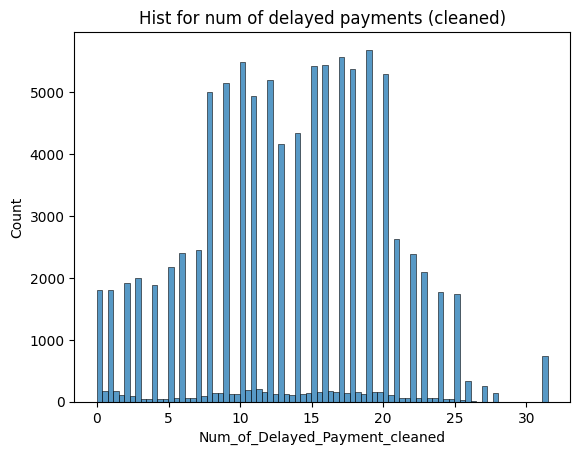

In [68]:
import seaborn as sns

_ = sns.histplot(
    train_sample_df,
    x="Num_of_Delayed_Payment_cleaned",
)

_.set_title("Hist for num of delayed payments (cleaned)")

In [69]:
train_sample_df["Payment_Behaviour"].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64

In [79]:
train_sample_df.groupby("Customer_ID")["Payment_Behaviour"].count().value_counts()

Payment_Behaviour
8    12500
Name: count, dtype: int64

In [77]:
train_sample_df[train_sample_df["Payment_Behaviour"] != "!@9#%8"].groupby(
    "Customer_ID"
)["Payment_Behaviour"].count().value_counts()

Payment_Behaviour
8    6600
7    4459
6    1210
5     205
4      24
3       2
Name: count, dtype: int64

In [80]:
train_sample_df["Payment_Behaviour"] = train_sample_df["Payment_Behaviour"].replace(
    "!@9#%8", np.nan
)

In [83]:
train_sample_df["Payment_Behaviour"] = train_sample_df["Payment_Behaviour"].fillna(
    train_sample_df.groupby("Customer_ID")["Payment_Behaviour"].bfill().ffill()
)

In [84]:
train_sample_df["Payment_Behaviour"].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      27610
High_spent_Medium_value_payments    18968
Low_spent_Medium_value_payments     15037
High_spent_Large_value_payments     14823
High_spent_Small_value_payments     12278
Low_spent_Large_value_payments      11284
Name: count, dtype: int64

In [87]:
pd.crosstab(
    train_sample_df["Payment_Behaviour"],
    train_sample_df["Credit_Score"],
    normalize=True,
)

Credit_Score,Good,Poor,Standard
Payment_Behaviour,,,
High_spent_Large_value_payments,0.03,0.03,0.08
High_spent_Medium_value_payments,0.04,0.05,0.10
High_spent_Small_value_payments,0.02,0.03,0.07
Low_spent_Large_value_payments,0.02,0.03,0.06
Low_spent_Medium_value_payments,0.03,0.05,0.08
Low_spent_Small_value_payments,0.04,0.10,0.14


### target:

In [89]:
train_sample_df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [ ]:
train_sample_df["Credit_Score"] = np.where(
    train_sample_df["Credit_Score"] == "Standard",
    "Good",
    train_sample_df["Credit_Score"],
)

train_sample_df["Credit_Score"].value_counts()["Credit_Score"].value_counts()

Credit_Score
Good    71002
Poor    28998
Name: count, dtype: int64

### Final

In [93]:
train_sample_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Annual_Income,"100,000.00","176,415.70","1,429,618.05","7,005.93","19,457.50","37,578.61","72,790.92","24,198,062.00"
Num_Credit_Inquiries,"100,000.00",5.99,4.13,0.00,3.00,6.00,9.00,18.00
Num_Bank_Accounts,"100,000.00",5.47,2.72,0.00,3.00,6.00,7.00,13.00
Num_of_Delayed_Payment_cleaned,"100,000.00",13.48,6.43,0.00,9.00,14.00,18.00,31.50


In [94]:
train_sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              100000 non-null  str    
 1   Customer_ID                     100000 non-null  str    
 2   Month                           100000 non-null  str    
 3   Occupation                      100000 non-null  str    
 4   Annual_Income                   100000 non-null  float64
 5   Num_Credit_Inquiries            100000 non-null  float64
 6   Num_Bank_Accounts               100000 non-null  int64  
 7   Num_of_Delayed_Payment          92998 non-null   str    
 8   Payment_Behaviour               100000 non-null  str    
 9   Credit_Score                    100000 non-null  str    
 10  Occupation_cleaned              100000 non-null  str    
 11  Num_of_Delayed_Payment_cleaned  100000 non-null  float64
dtypes: float64(3), int64(1), str

# EDA

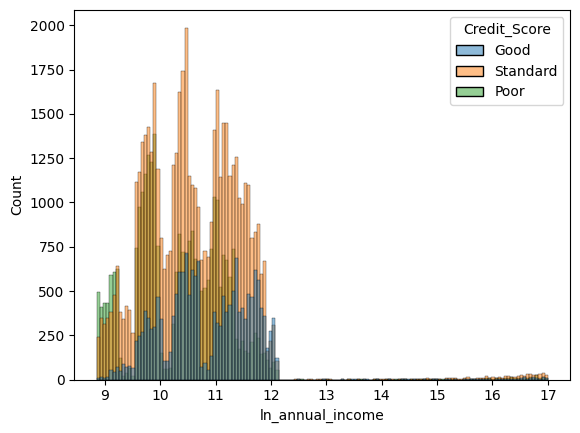

In [ ]:
import seaborn as sns

train_sample_df["ln_annual_income"] = np.log(train_sample_df["Annual_Income"])
_ = sns.histplot(train_sample_df, x="ln_annual_income", hue=target_col)

In [ ]:
p25 = train_sample_df["Annual_Income"].quantile(0.25)
p75 = train_sample_df["Annual_Income"].quantile(0.75)

irq = p75 - p25
upper = p75 + 1.5 * irq
lower = p25 - 1.5 * irq

print(lower, upper)

-60542.630000000005 152791.05


In [ ]:
plot_df = train_sample_df[train_sample_df["Annual_Income"] < upper]
plot_df.head()

,ID,Customer_ID,Month,Occupation,Annual_Income,Num_Credit_Inquiries,Num_Bank_Accounts,Num_of_Delayed_Payment,Payment_Behaviour,Credit_Score,Occupation_cleaned,ln_annual_income
0,0x1602,CUS_0xd40,January,Scientist,"19,114.12",4.00,3,7,High_spent_Small_value_payments,Good,Scientist,9.86
1,0x1603,CUS_0xd40,February,Scientist,"19,114.12",4.00,3,NaN,Low_spent_Large_value_payments,Good,Scientist,9.86
2,0x1604,CUS_0xd40,March,Scientist,"19,114.12",4.00,3,7,Low_spent_Medium_value_payments,Good,Scientist,9.86
3,0x1605,CUS_0xd40,April,Scientist,"19,114.12",4.00,3,4,Low_spent_Small_value_payments,Good,Scientist,9.86
4,0x1606,CUS_0xd40,May,Scientist,"19,114.12",4.00,3,NaN,High_spent_Medium_value_payments,Good,Scientist,9.86


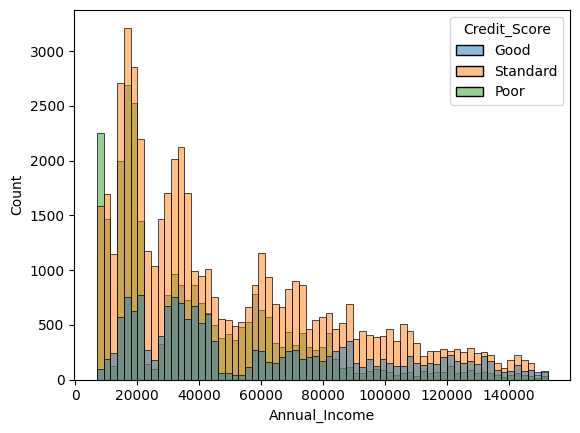

In [ ]:
_ = sns.histplot(plot_df, x="Annual_Income", hue=target_col)